# 3. 태양 위치 계산(altitude 고도, azimuth 방위각)

pysolar 사용법 익히기

## 1) import

In [10]:
import datetime
import pytz
import numpy as np
import matplotlib.pyplot as plt
from pysolar.solar import get_altitude, get_azimuth

## 2) 기준 위치(경북대 중심 좌표)

In [11]:
# ENU 변환할 때 쓰던 lat0, lng0 그대로 재사용해도 됨
lat0, lng0 = 35.888, 128.610   # 예시 (평균값 사용, 네 데이터 기반이면 더 정확)

print("기준 위치:", lat0, lng0)

기준 위치: 35.888 128.61


# 3) 특정 시간에서의 태양 위치

In [20]:
# 예: 2025년 6월 7일 15:00 KST (UTC+9)
dt_local = datetime.datetime(2025, 9, 6, 15, 0, 0, tzinfo=pytz.timezone("Asia/Seoul"))
dt_utc = dt_local.astimezone(pytz.UTC)

alt = get_altitude(lat0, lng0, dt_utc)   # 고도 (degrees)
az = get_azimuth(lat0, lng0, dt_utc)     # 방위각 (degrees)

print("태양 고도:", alt, "°")
print("태양 방위각:", az, "°")


태양 고도: 37.857887992455 °
태양 방위각: 247.045195265039 °


In [17]:
# 윈도우
rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 깨짐 방지
rcParams['axes.unicode_minus'] = False

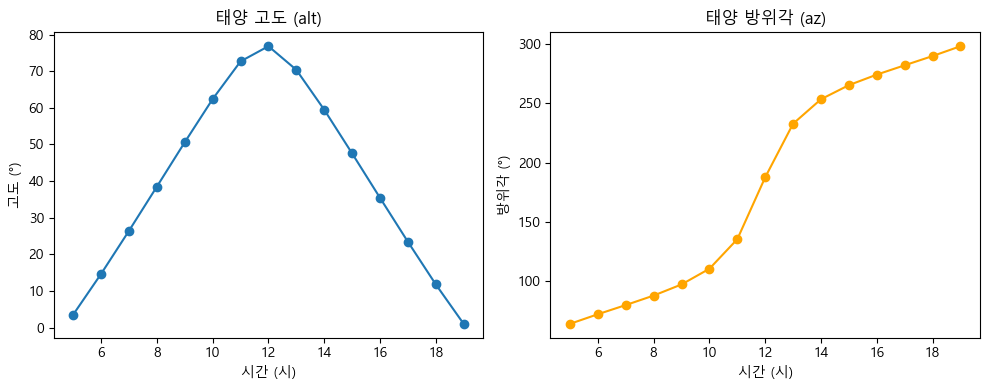

In [21]:
# 하루 동안 30분 간격 alt/az 계산
dt0 = datetime.datetime(2025, 9, 6, 5, 0, 0, tzinfo=pytz.timezone("Asia/Seoul"))
times, alts, azs = [], [], []

for h in range(5, 20):   # 05:00 ~ 19:00
    dt_local = datetime.datetime(2024, 6, 7, h, 0, 0, tzinfo=pytz.timezone("Asia/Seoul"))
    dt_utc = dt_local.astimezone(pytz.UTC)
    times.append(h)
    alts.append(get_altitude(lat0, lng0, dt_utc))
    azs.append(get_azimuth(lat0, lng0, dt_utc))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(times, alts, marker="o")
plt.title("태양 고도 (alt)")
plt.xlabel("시간 (시)")
plt.ylabel("고도 (°)")

plt.subplot(1,2,2)
plt.plot(times, azs, marker="o", color="orange")
plt.title("태양 방위각 (az)")
plt.xlabel("시간 (시)")
plt.ylabel("방위각 (°)")

plt.tight_layout()
plt.show()
